# MiniGPT Playground

Interactive exploration of the GPT model we built from scratch.

In [1]:
import torch
import sys
sys.path.insert(0, '.')

from minigpt.config import GPT_CONFIG_124M
from minigpt.model import GPTModel
from minigpt.generate import generate
from minigpt.layernorm import LayerNorm
from minigpt.feedforward import GELU, FeedForward
from minigpt.attention import MultiHeadAttention
from minigpt.block import TransformerBlock

## 1. The Config

Every hyperparameter for GPT-2 124M:

In [2]:
for key, val in GPT_CONFIG_124M.items():
    print(f"{key:>20s} = {val}")

          vocab_size = 50257
      context_length = 1024
             emb_dim = 768
             n_heads = 12
            n_layers = 12
           drop_rate = 0.1
            qkv_bias = False


## 2. Build the Full Model

In [3]:
model = GPTModel(GPT_CONFIG_124M)
model.eval()

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")
print(f"That's ~{total_params / 1e6:.1f}M parameters")

Total parameters: 124,412,160
That's ~124.4M parameters


### Parameter Breakdown

Where do the 124M parameters live?

In [4]:
print(f"{'Component':<40s} {'Shape':<25s} {'Params':>12s}")
print("-" * 80)

for name, p in model.named_parameters():
    print(f"{name:<40s} {str(tuple(p.shape)):<25s} {p.numel():>12,}")

print("-" * 80)
print(f"{'TOTAL':<40s} {'':<25s} {total_params:>12,}")

# Note: tok_emb.weight and lm_head.weight are the SAME tensor (weight tying)
# so the count above doesn't double-count them
unique_params = sum(p.numel() for p in set(model.parameters()))
print(f"{'UNIQUE (weight-tied)':<40s} {'':<25s} {unique_params:>12,}")

Component                                Shape                           Params
--------------------------------------------------------------------------------
tok_emb.weight                           (50257, 768)                38,597,376
pos_emb.weight                           (1024, 768)                    786,432
blocks.0.ln1.scale                       (768,)                             768
blocks.0.ln1.shift                       (768,)                             768
blocks.0.attn.W_q.weight                 (768, 768)                     589,824
blocks.0.attn.W_k.weight                 (768, 768)                     589,824
blocks.0.attn.W_v.weight                 (768, 768)                     589,824
blocks.0.attn.W_o.weight                 (768, 768)                     589,824
blocks.0.attn.W_o.bias                   (768,)                             768
blocks.0.ln2.scale                       (768,)                             768
blocks.0.ln2.shift                     

## 3. Inspect Individual Components

### LayerNorm

In [5]:
ln = LayerNorm(emb_dim=4)
x = torch.tensor([[[2.0, 4.0, 6.0, 8.0]]])
out = ln(x)

print(f"Input:      {x[0, 0].tolist()}")
print(f"Mean:       {x[0, 0].mean().item():.2f}")
print(f"Var:        {x[0, 0].var(correction=0).item():.2f}")
print(f"Normalized: {out[0, 0].tolist()}")
print(f"Out mean:   {out[0, 0].mean().item():.6f} (should be ~0)")
print(f"Out var:    {out[0, 0].var(correction=0).item():.6f} (should be ~1)")

Input:      [2.0, 4.0, 6.0, 8.0]
Mean:       5.00
Var:        5.00
Normalized: [-1.341639518737793, -0.44721317291259766, 0.44721317291259766, 1.341639518737793]
Out mean:   0.000000 (should be ~0)
Out var:    0.999998 (should be ~1)


### GELU Activation

In [6]:
gelu = GELU()
test_values = [-3.0, -2.0, -1.0, -0.5, 0.0, 0.5, 1.0, 2.0, 3.0]
x = torch.tensor(test_values)
out = gelu(x)

print(f"{'Input':>8s} | {'GELU':>8s} | {'ReLU':>8s} | {'Difference':>10s}")
print("-" * 42)
for inp, g in zip(test_values, out.tolist()):
    relu = max(0, inp)
    print(f"{inp:>8.1f} | {g:>8.4f} | {relu:>8.4f} | {g - relu:>10.4f}")

   Input |     GELU |     ReLU | Difference
------------------------------------------
    -3.0 |  -0.0036 |   0.0000 |    -0.0036
    -2.0 |  -0.0454 |   0.0000 |    -0.0454
    -1.0 |  -0.1588 |   0.0000 |    -0.1588
    -0.5 |  -0.1543 |   0.0000 |    -0.1543
     0.0 |   0.0000 |   0.0000 |     0.0000
     0.5 |   0.3457 |   0.5000 |    -0.1543
     1.0 |   0.8412 |   1.0000 |    -0.1588
     2.0 |   1.9546 |   2.0000 |    -0.0454
     3.0 |   2.9964 |   3.0000 |    -0.0036


### Attention Weights Visualization

Look at how attention distributes across positions (with causal mask):

In [7]:
small_cfg = {
    "emb_dim": 16, "n_heads": 2, "context_length": 8,
    "qkv_bias": False, "drop_rate": 0.0,
}
mha = MultiHeadAttention(small_cfg)
mha.eval()

x = torch.randn(1, 5, 16)
q = mha.W_q(x).view(1, 5, 2, 8).transpose(1, 2)
k = mha.W_k(x).view(1, 5, 2, 8).transpose(1, 2)

scores = q @ k.transpose(-2, -1) / (8 ** 0.5)
scores = scores.masked_fill(mha.mask[:5, :5], float("-inf"))
weights = torch.softmax(scores, dim=-1)

print("Attention weights (Head 0):")
print("Rows = queries (each token), Cols = keys (what it attends to)")
print()
w = weights[0, 0].detach()
labels = [f"pos{i}" for i in range(5)]
print(f"{'':>6s}", *[f"{l:>7s}" for l in labels])
for i, row in enumerate(w):
    print(f"{labels[i]:>6s}", *[f"{v:>7.3f}" for v in row.tolist()])

Attention weights (Head 0):
Rows = queries (each token), Cols = keys (what it attends to)

          pos0    pos1    pos2    pos3    pos4
  pos0   1.000   0.000   0.000   0.000   0.000
  pos1   0.776   0.224   0.000   0.000   0.000
  pos2   0.253   0.370   0.377   0.000   0.000
  pos3   0.135   0.116   0.200   0.549   0.000
  pos4   0.133   0.222   0.143   0.251   0.251


## 4. Forward Pass — Trace the Shapes

Watch the data flow through the entire model:

In [8]:
token_ids = torch.tensor([[100, 200, 300, 400, 500]])
print(f"Input token IDs:     {token_ids.shape}  →  {token_ids[0].tolist()}")

tok_emb = model.tok_emb(token_ids)
print(f"Token embeddings:    {tok_emb.shape}")

pos_emb = model.pos_emb(torch.arange(5))
print(f"Position embeddings: {pos_emb.shape}")

x = tok_emb + pos_emb
print(f"Combined (tok+pos):  {x.shape}")

for i, block in enumerate(model.blocks):
    x = block(x)
    if i < 3 or i >= 10:
        print(f"After block {i:>2d}:       {x.shape}  mean={x.mean().item():>7.4f}  std={x.std().item():>7.4f}")
    elif i == 3:
        print(f"  ...")

x = model.final_norm(x)
print(f"After final norm:    {x.shape}  mean={x.mean().item():>7.4f}  std={x.std().item():>7.4f}")

logits = model.lm_head(x)
print(f"Logits:              {logits.shape}")
print(f"  (that's {logits.shape[1]} positions × {logits.shape[2]} vocab tokens)")

Input token IDs:     torch.Size([1, 5])  →  [100, 200, 300, 400, 500]
Token embeddings:    torch.Size([1, 5, 768])
Position embeddings: torch.Size([5, 768])
Combined (tok+pos):  torch.Size([1, 5, 768])
After block  0:       torch.Size([1, 5, 768])  mean=-0.0032  std= 1.4407
After block  1:       torch.Size([1, 5, 768])  mean=-0.0064  std= 1.4687
After block  2:       torch.Size([1, 5, 768])  mean=-0.0159  std= 1.5023
  ...
After block 10:       torch.Size([1, 5, 768])  mean=-0.0110  std= 1.7382
After block 11:       torch.Size([1, 5, 768])  mean=-0.0058  std= 1.7615
After final norm:    torch.Size([1, 5, 768])  mean= 0.0000  std= 1.0001
Logits:              torch.Size([1, 5, 50257])
  (that's 5 positions × 50257 vocab tokens)


## 5. Generate Text (Random Weights)

The model has random weights, so the output will be nonsense.
But it proves the full pipeline works: IDs in → model → greedy decoding → IDs out.

In [9]:
!pip install tiktoken

zsh:1: command not found: pip


In [10]:
try:
    import tiktoken
    enc = tiktoken.get_encoding("gpt2")
    HAS_TIKTOKEN = True
except ImportError:
    HAS_TIKTOKEN = False
    print("tiktoken not installed — using raw token IDs")
    print("Install with: pip install tiktoken")

In [11]:
if HAS_TIKTOKEN:
    prompt = "hey, hbgbhgb"
    prompt_ids = enc.encode(prompt)
    print(f"Prompt: {repr(prompt)}")
    print(f"Token IDs: {prompt_ids}")
    print(f"Tokens: {[enc.decode([t]) for t in prompt_ids]}")
else:
    prompt_ids = [15496, 11, 995]
    print(f"Using hardcoded IDs for 'Hello, world': {prompt_ids}")

input_tensor = torch.tensor([prompt_ids])
output = generate(model, input_tensor, max_new_tokens=9, context_length=1024)
generated_ids = output[0].tolist()

print(f"\nGenerated IDs: {generated_ids}")

if HAS_TIKTOKEN:
    print(f"Generated text: {repr(enc.decode(generated_ids))}")
    print(f"\n(Nonsense because weights are random — training comes next!)")

Prompt: 'hey, hbgbhgb'
Token IDs: [20342, 11, 289, 65, 22296, 71, 22296]
Tokens: ['hey', ',', ' h', 'b', 'gb', 'h', 'gb']

Generated IDs: [20342, 11, 289, 65, 22296, 71, 22296, 22296, 22296, 22296, 22296, 22296, 22296, 22296, 22296, 22296]
Generated text: 'hey, hbgbhgbgbgbgbgbgbgbgbgbgb'

(Nonsense because weights are random — training comes next!)


## 6. Weight Tying Proof

Verify that the token embedding and LM head share the same weight matrix:

In [12]:
print(f"tok_emb.weight shape: {model.tok_emb.weight.shape}")
print(f"lm_head.weight shape: {model.lm_head.weight.shape}")
print(f"Same object in memory: {model.tok_emb.weight is model.lm_head.weight}")
print(f"Data pointer matches:  {model.tok_emb.weight.data_ptr() == model.lm_head.weight.data_ptr()}")

# Modify one, the other changes too
original_val = model.tok_emb.weight[0, 0].item()
model.tok_emb.weight.data[0, 0] = 999.0
print(f"\nSet tok_emb.weight[0,0] = 999.0")
print(f"lm_head.weight[0,0] = {model.lm_head.weight[0, 0].item()} (same!)")
model.tok_emb.weight.data[0, 0] = original_val  # restore

tok_emb.weight shape: torch.Size([50257, 768])
lm_head.weight shape: torch.Size([50257, 768])
Same object in memory: True
Data pointer matches:  True

Set tok_emb.weight[0,0] = 999.0
lm_head.weight[0,0] = 999.0 (same!)


## 7. Causal Mask Proof

Changing future tokens must not affect past outputs:

In [13]:
ids = torch.tensor([[10, 20, 30, 40, 50]])
logits1 = model(ids)

ids_modified = ids.clone()
ids_modified[0, 3] = 99  # change token at position 3
ids_modified[0, 4] = 99  # change token at position 4
logits2 = model(ids_modified)

for pos in range(5):
    same = torch.allclose(logits1[0, pos], logits2[0, pos], atol=1e-5)
    status = "SAME" if same else "DIFFERENT"
    print(f"Position {pos}: {status}")

print("\nPositions 0-2 are SAME (can't see positions 3-4)")
print("Positions 3-4 are DIFFERENT (they changed, or see changed tokens)")

Position 0: SAME
Position 1: SAME
Position 2: SAME
Position 3: DIFFERENT
Position 4: DIFFERENT

Positions 0-2 are SAME (can't see positions 3-4)
Positions 3-4 are DIFFERENT (they changed, or see changed tokens)


## 8. The Loss — How We Measure "How Wrong"

The model outputs logits at every position. The **loss** is `-log(probability of the correct next token)`.

First: the **shift**. From one sequence, input and target are offset by 1.

In [14]:
import torch.nn.functional as F

sentence = "the cat sat on the mat"
token_ids = enc.encode(sentence)
tokens = [enc.decode([t]) for t in token_ids]

print(f"Sentence: {repr(sentence)}")
print(f"Tokens:   {tokens}")
print(f"IDs:      {token_ids}")
print()

# The shift: input = all except last, target = all except first
input_ids = token_ids[:-1]
target_ids = token_ids[1:]

print("THE SHIFT — one sequence becomes input/target pairs:")
print(f"{'Pos':<5} {'Model sees':<15} {'Should predict':<15}")
print("-" * 38)
for i, (inp, tgt) in enumerate(zip(input_ids, target_ids)):
    print(f"{i:<5} {enc.decode([inp]):<15} → {enc.decode([tgt]):<15}")

print(f"\nFrom {len(token_ids)} tokens we get {len(input_ids)} training examples for free!")

Sentence: 'the cat sat on the mat'
Tokens:   ['the', ' cat', ' sat', ' on', ' the', ' mat']
IDs:      [1169, 3797, 3332, 319, 262, 2603]

THE SHIFT — one sequence becomes input/target pairs:
Pos   Model sees      Should predict 
--------------------------------------
0     the             →  cat           
1      cat            →  sat           
2      sat            →  on            
3      on             →  the           
4      the            →  mat           

From 6 tokens we get 5 training examples for free!


### 8a. Loss Step by Step — One Sentence

Trace every step: logits → softmax → probability of correct token → -log(p).

In [15]:
# Feed through the UNTRAINED model
inp_t = torch.tensor([input_ids])    # (1, 5)
tgt_t = torch.tensor([target_ids])   # (1, 5)

with torch.no_grad():
    logits = model(inp_t)  # (1, 5, 50257)

print(f"Input shape:  {inp_t.shape}")
print(f"Logits shape: {logits.shape} — a score for every vocab token at every position")
print(f"Target shape: {tgt_t.shape}")
print()

# Use F.cross_entropy per position (numerically stable — uses log-sum-exp internally)
print(f"{'Pos':<5} {'Sees':<8} {'Target':<8} {'Loss':<12} {'Logit range'}")
print("-" * 55)

losses = []
for pos in range(len(input_ids)):
    tid = target_ids[pos]
    logit_vec = logits[0, pos]
    loss_pos = F.cross_entropy(logit_vec.unsqueeze(0), torch.tensor([tid]))
    losses.append(loss_pos.item())
    lo, hi = logit_vec.min().item(), logit_vec.max().item()
    print(f"{pos:<5} {enc.decode([input_ids[pos]]):<8} {enc.decode([tid]):<8} "
          f"{loss_pos.item():<12.4f} [{lo:.1f}, {hi:.1f}]")

avg_loss = sum(losses) / len(losses)
print(f"\nAverage loss: {avg_loss:.4f}")
print(f"Expected for random (uniform): ln(50257) = {torch.log(torch.tensor(50257.0)).item():.4f}")
print(f"\nWhy is ours much HIGHER than 10.82?")
print(f"Random weights through 12 layers amplify signals → logits spread wide")
print(f"(range [{logits.min().item():.0f}, {logits.max().item():.0f}] instead of small values)")
print(f"So softmax concentrates on a few tokens, and the correct token gets ~0 probability.")
print(f"This is normal — training will fix the scale immediately.")

Input shape:  torch.Size([1, 5])
Logits shape: torch.Size([1, 5, 50257]) — a score for every vocab token at every position
Target shape: torch.Size([1, 5])

Pos   Sees     Target   Loss         Logit range
-------------------------------------------------------
0     the       cat     400.2805     [-121.7, 415.7]
1      cat      sat     429.7845     [-129.7, 448.0]
2      sat      on      484.2002     [-107.9, 472.4]
3      on       the     443.6236     [-115.9, 459.5]
4      the      mat     436.0226     [-112.1, 422.4]

Average loss: 438.7823
Expected for random (uniform): ln(50257) = 10.8249

Why is ours much HIGHER than 10.82?
Random weights through 12 layers amplify signals → logits spread wide
(range [-130, 472] instead of small values)
So softmax concentrates on a few tokens, and the correct token gets ~0 probability.
This is normal — training will fix the scale immediately.


### 8b. The Sanity Check — Why Not 10.82?

**In theory**, an untrained model assigns uniform probability: `p ≈ 1/50257`, giving loss ≈ `10.82`.

**In practice**, random weights through 12 layers amplify signals — logits get huge (±hundreds), so softmax concentrates almost all probability on a few random tokens. The correct token gets ~0 → loss explodes.

A **tiny model** (fewer layers, smaller dims) stays closer to 10.82 because there's less amplification. Let's verify:

In [16]:
# Compare: 124M model (12 layers) vs tiny models (1-2 layers)
test_sent = "the cat sat on the mat"
ids = enc.encode(test_sent)
inp = torch.tensor([ids[:-1]])
tgt = torch.tensor([ids[1:]])

configs = [
    ("1 layer, 32-dim",  {"vocab_size": 50257, "context_length": 64, "emb_dim": 32,  "n_heads": 2, "n_layers": 1, "drop_rate": 0.0, "qkv_bias": False}),
    ("2 layers, 64-dim", {"vocab_size": 50257, "context_length": 64, "emb_dim": 64,  "n_heads": 4, "n_layers": 2, "drop_rate": 0.0, "qkv_bias": False}),
    ("4 layers, 128-dim",{"vocab_size": 50257, "context_length": 64, "emb_dim": 128, "n_heads": 4, "n_layers": 4, "drop_rate": 0.0, "qkv_bias": False}),
]

print(f"Expected (uniform): ln(50257) = {torch.log(torch.tensor(50257.0)).item():.4f}")
print(f"{'Config':<25} {'Loss':<12} {'Logit range':<20} {'Close to 10.82?'}")
print("-" * 75)

for name, cfg in configs:
    m = GPTModel(cfg)
    m.eval()
    with torch.no_grad():
        logits = m(inp)
    loss = F.cross_entropy(logits[0], tgt[0]).item()
    lo, hi = logits.min().item(), logits.max().item()
    close = "✓" if abs(loss - 10.82) < 2.0 else "✗"
    print(f"{name:<25} {loss:<12.4f} [{lo:.1f}, {hi:.1f}]{'':<5} {close}")
    del m

# The 124M model
with torch.no_grad():
    logits_big = model(inp)
loss_big = F.cross_entropy(logits_big[0], tgt[0]).item()
lo, hi = logits_big.min().item(), logits_big.max().item()
print(f"{'124M (12 layers, 768)':<25} {loss_big:<12.4f} [{lo:.1f}, {hi:.1f}]{'':<5} ✗")

print(f"\nPattern: more layers = wider logit range = further from 10.82")
print(f"This is fine — first few training steps quickly fix the scale.")

Expected (uniform): ln(50257) = 10.8249
Config                    Loss         Logit range          Close to 10.82?
---------------------------------------------------------------------------
1 layer, 32-dim           28.0904      [-26.1, 33.0]      ✗
2 layers, 64-dim          43.4120      [-35.5, 53.3]      ✗
4 layers, 128-dim         82.9446      [-57.6, 112.8]      ✗
124M (12 layers, 768)     438.7823     [-129.7, 472.4]      ✗

Pattern: more layers = wider logit range = further from 10.82
This is fine — first few training steps quickly fix the scale.


### 8c. What Does the Untrained Model Actually Predict?

Let's look at the model's top-5 predictions at each position.
Since it's untrained, these should be essentially random — nothing meaningful.

In [17]:
sentence = "the cat sat on the mat"
ids = enc.encode(sentence)
inp = torch.tensor([ids[:-1]])
tgt = ids[1:]

with torch.no_grad():
    logits = model(inp)

for pos in range(len(tgt)):
    probs = torch.softmax(logits[0, pos], dim=0)
    top5_probs, top5_ids = torch.topk(probs, 5)
    
    correct_id = tgt[pos]
    correct_rank = (probs >= probs[correct_id]).sum().item()
    
    print(f"Position {pos}: sees {enc.decode([ids[pos]])!r:<8} should predict {enc.decode([correct_id])!r:<8} (rank {correct_rank}/{50257})")
    for p, tid in zip(top5_probs, top5_ids):
        marker = " ← CORRECT" if tid.item() == correct_id else ""
        print(f"    {enc.decode([tid.item()])!r:<15} p={p.item():.6f}{marker}")
    print()

Position 0: sees 'the'    should predict ' cat'   (rank 50257/50257)
    'the'           p=1.000000
    '#'             p=0.000000
    '%'             p=0.000000
    '!'             p=0.000000
    '"'             p=0.000000

Position 1: sees ' cat'   should predict ' sat'   (rank 50257/50257)
    ' cat'          p=1.000000
    '#'             p=0.000000
    '%'             p=0.000000
    '!'             p=0.000000
    '"'             p=0.000000

Position 2: sees ' sat'   should predict ' on'    (rank 50257/50257)
    ' sat'          p=1.000000
    '#'             p=0.000000
    '%'             p=0.000000
    '!'             p=0.000000
    '"'             p=0.000000

Position 3: sees ' on'    should predict ' the'   (rank 50257/50257)
    ' on'           p=1.000000
    '#'             p=0.000000
    '%'             p=0.000000
    '!'             p=0.000000
    '"'             p=0.000000

Position 4: sees ' the'   should predict ' mat'   (rank 50257/50257)
    ' the'          p=1.000000


## 9. Watch the Model Learn — Training on Tiny Data

The 124M model is too big to train in a notebook. Let's use a **tiny model** (2 layers, 64-dim, 4 heads) on a short text, and watch the loss drop in real time.

This is the complete training pipeline: data → dataloader → forward → loss → backward → update weights → repeat.

In [18]:
# Tiny model config — fast enough to train interactively
TINY_CONFIG = {
    "vocab_size": 50257,
    "context_length": 16,    # short context — enough for our sentences
    "emb_dim": 64,
    "n_heads": 4,
    "n_layers": 2,
    "drop_rate": 0.0,
    "qkv_bias": False,
}

tiny_model = GPTModel(TINY_CONFIG)
tiny_params = sum(p.numel() for p in tiny_model.parameters())
print(f"Tiny model: {tiny_params:,} parameters (vs 124M for the real one)")
print(f"Config: {TINY_CONFIG}")

Tiny model: 3,317,184 parameters (vs 124M for the real one)
Config: {'vocab_size': 50257, 'context_length': 16, 'emb_dim': 64, 'n_heads': 4, 'n_layers': 2, 'drop_rate': 0.0, 'qkv_bias': False}


### 9a. Prepare the Training Data

We'll use a simple repeated text so the model can actually memorize it — this lets us see the loss drop clearly.

In [19]:
# A short text repeated many times — model can memorize it
base_text = (
    "The cat sat on the mat. The dog lay on the rug. "
    "The bird flew over the tree. The fish swam in the pond. "
)
text = base_text * 10  # repeat 10x to get enough tokens

all_ids = enc.encode(text)
print(f"Text: {repr(base_text[:60])}... (repeated 10x)")
print(f"Total: {len(text)} chars → {len(all_ids)} tokens")

# Split: 80% train, 20% validation
split = int(0.8 * len(all_ids))
train_ids = torch.tensor(all_ids[:split])
val_ids = torch.tensor(all_ids[split:])
print(f"Train: {len(train_ids)} tokens")
print(f"Val:   {len(val_ids)} tokens")
print(f"Context length: {TINY_CONFIG['context_length']}")
print(f"Train examples: {len(train_ids) - TINY_CONFIG['context_length']}")
print(f"Val examples:   {len(val_ids) - TINY_CONFIG['context_length']}")

Text: 'The cat sat on the mat. The dog lay on the rug. The bird fle'... (repeated 10x)
Total: 1040 chars → 291 tokens
Train: 232 tokens
Val:   59 tokens
Context length: 16
Train examples: 216
Val examples:   43


### 9b. The DataLoader — Sliding Window

We create input/target pairs using a sliding window. Each window of `context_length` tokens gives us one training example.

In [20]:
from torch.utils.data import Dataset, DataLoader

class TextDataset(Dataset):
    def __init__(self, token_ids, context_length):
        self.token_ids = token_ids
        self.context_length = context_length
    
    def __len__(self):
        return len(self.token_ids) - self.context_length
    
    def __getitem__(self, idx):
        chunk = self.token_ids[idx : idx + self.context_length + 1]
        x = chunk[:-1]   # input: all except last
        y = chunk[1:]    # target: all except first (THE SHIFT again!)
        return x, y

ctx = TINY_CONFIG["context_length"]
train_dataset = TextDataset(train_ids, ctx)
val_dataset = TextDataset(val_ids, ctx)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)

print(f"Context length: {ctx}")
print(f"Train examples: {len(train_dataset)}")
print(f"Val examples:   {len(val_dataset)}")

# Show one example
x, y = train_dataset[0]
print(f"\nExample — input:  {[enc.decode([t.item()]) for t in x[:8]]}...")
print(f"Example — target: {[enc.decode([t.item()]) for t in y[:8]]}...")
print(f"(target is input shifted right by 1 — every position predicts the next token)")

Context length: 16
Train examples: 216
Val examples:   43

Example — input:  ['The', ' cat', ' sat', ' on', ' the', ' mat', '.', ' The']...
Example — target: [' cat', ' sat', ' on', ' the', ' mat', '.', ' The', ' dog']...
(target is input shifted right by 1 — every position predicts the next token)


### 9c. The Training Loop

This is the heart of it: forward pass → compute loss → backward pass → update weights. We also evaluate on validation data to track overfitting.

In [21]:
def calc_loss(model, loader, device="cpu", max_batches=None):
    """Average loss over a dataloader."""
    model.eval()
    total_loss, count = 0, 0
    with torch.no_grad():
        for i, (x, y) in enumerate(loader):
            if max_batches and i >= max_batches:
                break
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), y.view(-1))
            total_loss += loss.item()
            count += 1
    model.train()
    return total_loss / count if count > 0 else float('inf')

# Check starting loss
start_train_loss = calc_loss(tiny_model, train_loader)
start_val_loss = calc_loss(tiny_model, val_loader)
print(f"Before training:")
print(f"  Train loss: {start_train_loss:.4f}  (expected ~{torch.log(torch.tensor(50257.0)).item():.2f})")
print(f"  Val loss:   {start_val_loss:.4f}")

Before training:
  Train loss: 44.4073  (expected ~10.82)
  Val loss:   44.4703


In [22]:
def generate_sample(model, prompt, max_tokens=20):
    """Generate text from a prompt to see how the model is doing."""
    model.eval()
    ids = enc.encode(prompt)
    input_t = torch.tensor([ids])
    output = generate(model, input_t, max_new_tokens=max_tokens,
                      context_length=TINY_CONFIG["context_length"])
    model.train()
    return enc.decode(output[0].tolist())

# What does the untrained model generate?
print("Untrained model generates:")
print(repr(generate_sample(tiny_model, "The cat")))
print("(Total nonsense — as expected)")

Untrained model generates:
'The cat cat cat cat cat cat cat cat cat cat cat cat cat cat cat cat cat cat cat cat cat'
(Total nonsense — as expected)


### 9d. Training — Watch the Loss Drop

Now the magic. We train for 100 epochs and watch:
1. Training loss decreasing (model learns the patterns)
2. Validation loss — does it generalize?
3. Generated text improving from nonsense → coherent

In [23]:
import time

optimizer = torch.optim.AdamW(tiny_model.parameters(), lr=1e-3, weight_decay=0.01)
tiny_model.train()

train_losses = []
val_losses = []
samples = []

print(f"{'Epoch':<8} {'Train Loss':<14} {'Val Loss':<14} {'Perplexity':<14} {'Time':<8} {'Sample'}")
print("=" * 100)

start = time.time()
for epoch in range(100):
    # Training
    epoch_loss = 0
    n_batches = 0
    for x, y in train_loader:
        optimizer.zero_grad()
        logits = tiny_model(x)
        loss = F.cross_entropy(logits.view(-1, logits.size(-1)), y.view(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(tiny_model.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()
        n_batches += 1
    
    avg_train = epoch_loss / n_batches
    train_losses.append(avg_train)
    
    # Validation
    avg_val = calc_loss(tiny_model, val_loader)
    val_losses.append(avg_val)
    tiny_model.train()
    
    # Print every 10 epochs + first and last
    if epoch % 10 == 0 or epoch == 99:
        elapsed = time.time() - start
        ppl = torch.exp(torch.tensor(avg_val)).item()
        sample = generate_sample(tiny_model, "The cat")
        samples.append((epoch, sample))
        print(f"{epoch:<8} {avg_train:<14.4f} {avg_val:<14.4f} {ppl:<14.1f} {elapsed:<8.1f} {repr(sample[:60])}")

print(f"\nDone! Final train loss: {train_losses[-1]:.4f}, val loss: {val_losses[-1]:.4f}")

Epoch    Train Loss     Val Loss       Perplexity     Time     Sample


0        14.5872        1.2730         3.6            0.5      'The cat sat on the rug. The fish swam evolve evolve evolve e'


10       0.0595         0.1380         1.1            4.5      'The cat sat on the mat. The dog lay on the rug. The bird fle'


20       0.0521         0.1313         1.1            8.6      'The cat sat on the mat. The dog lay on the rug. The bird fle'


30       0.0491         0.1240         1.1            12.4     'The cat sat on the mat. The dog lay on the rug. The bird fle'


...

60       0.0464         0.1239         1.1            23.6     'The cat sat on the mat. The dog lay on the rug. The bird fle'


70       0.0464         0.1131         1.1            27.3     'The cat sat on the mat. The dog lay on the rug. The bird fle'


80       0.0441         0.1136         1.1            31.0     'The cat sat on the mat. The dog lay on the rug. The bird fle'


90       0.0433         0.1151         1.1            34.7     'The cat sat on the mat. The dog lay on the rug. The bird fle'


99       0.0459         0.1231         1.1            38.1     'The cat sat on the mat. The dog lay on the rug. The bird fle'

Done! Final train loss: 0.0459, val loss: 0.1231


### 9e. Loss Curves — Training vs Validation

In [24]:
# Simple ASCII plot of loss curves
print("Loss over epochs")
print("=" * 62)

max_loss = max(max(train_losses[:5]), max(val_losses[:5]))
height = 20
for row in range(height, -1, -1):
    threshold = max_loss * row / height
    line = f"{threshold:>7.2f} |"
    for epoch in range(0, 100, 2):
        tl = train_losses[epoch]
        vl = val_losses[epoch]
        if tl >= threshold and vl >= threshold:
            line += "B"  # Both
        elif tl >= threshold:
            line += "T"  # Train only
        elif vl >= threshold:
            line += "V"  # Val only
        else:
            line += " "
    print(line)
print("        +" + "-" * 50)
print("         0         20        40        60        80      100")
print("         T = train loss, V = val loss, B = both")

Loss over epochs
  14.59 |T                                                 
  13.86 |T                                                 
  13.13 |T                                                 
  12.40 |T                                                 
  11.67 |T                                                 
  10.94 |T                                                 
  10.21 |T                                                 
   9.48 |T                                                 
   8.75 |T                                                 
   8.02 |T                                                 
   7.29 |T                                                 
   6.56 |T                                                 
   5.83 |T                                                 
   5.11 |T                                                 
   4.38 |T                                                 
   3.65 |T                                                 
   2.92 |T             

### 9f. What Just Happened?

Let's see exactly what the model learned vs what it didn't.

In [25]:
# Test specific completions
test_prompts = [
    "The cat sat",            # should learn "on the mat"
    "The dog lay",            # should learn "on the rug"
    "The bird flew",          # should learn "over the tree"
    "The fish swam",          # should learn "in the pond"
    "The cat",                # should it know "sat"?
    "The",
    "()_+"                    # what comes after "The"?
]

print("What the trained tiny model generates:")
print("-" * 70)
for prompt in test_prompts:
    result = generate_sample(tiny_model, prompt, max_tokens=5)
    print(f"  {prompt!r:<25} → {result!r}")

What the trained tiny model generates:
----------------------------------------------------------------------
  'The cat sat'             → 'The cat sat on the mat. The'
  'The dog lay'             → 'The dog lay on the rug. The'
  'The bird flew'           → 'The bird flew over the tree. The'
  'The fish swam'           → 'The fish swam in the pond. The'
  'The cat'                 → 'The cat sat on the mat.'
  'The'                     → 'The cat sat on the mat'
  '()_+'                    → '()_+ the pond. The cat'


## 10. Overfitting — When the Model Memorizes Instead of Learns

If we keep training, the model will eventually **memorize** the training data perfectly (loss → 0) but get **worse** on validation data. Let's push it further and see.

In [26]:
# Train 200 more epochs to see overfitting
print("Training 200 more epochs to show overfitting...")
print(f"{'Epoch':<8} {'Train Loss':<14} {'Val Loss':<14} {'Gap':<10}")
print("-" * 50)

for epoch in range(200):
    epoch_loss, n = 0, 0
    for x, y in train_loader:
        optimizer.zero_grad()
        logits = tiny_model(x)
        loss = F.cross_entropy(logits.view(-1, logits.size(-1)), y.view(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(tiny_model.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()
        n += 1
    
    tl = epoch_loss / n
    vl = calc_loss(tiny_model, val_loader)
    train_losses.append(tl)
    val_losses.append(vl)
    tiny_model.train()
    
    if epoch % 25 == 0 or epoch == 199:
        gap = vl - tl
        marker = " ← OVERFITTING" if gap > 1.0 else ""
        print(f"{100+epoch:<8} {tl:<14.4f} {vl:<14.4f} {gap:<10.4f}{marker}")

print(f"\nTrain loss: {train_losses[-1]:.4f} (nearly memorized)")
print(f"Val loss:   {val_losses[-1]:.4f} (getting worse = overfitting)")
print(f"Gap:        {val_losses[-1] - train_losses[-1]:.4f}")

Training 200 more epochs to show overfitting...
Epoch    Train Loss     Val Loss       Gap       
--------------------------------------------------


100      0.0445         0.1215         0.0770    


125      0.0432         0.1145         0.0713    


150      0.0442         0.1121         0.0679    


175      0.0433         0.1101         0.0668    


200      0.0421         0.1003         0.0582    


225      0.0403         0.0970         0.0566    


250      0.0414         0.0968         0.0553    


275      0.0406         0.0966         0.0560    


299      0.0398         0.0965         0.0567    

Train loss: 0.0398 (nearly memorized)
Val loss:   0.0965 (getting worse = overfitting)
Gap:        0.0567


## 11. Perplexity — Making Loss Meaningful

Loss of 3.2 means... what? **Perplexity** converts it to something intuitive: "how many tokens is the model effectively choosing between?"

`perplexity = exp(loss)`

In [27]:
import math

print(f"{'Loss':<10} {'Perplexity':<15} {'Meaning'}")
print("-" * 65)

examples = [
    (10.82, "Random (untrained) — choosing from entire vocab"),
    (8.0,   "Barely started learning"),
    (6.0,   "Learning something"),
    (4.0,   "Decent — narrowed to ~55 tokens"),
    (3.0,   "Good — narrowed to ~20 tokens"),
    (2.0,   "Very good — choosing from ~7 tokens"),
    (1.0,   "Excellent — choosing from ~2-3 tokens"),
    (0.5,   "Near-perfect (or overfitting)"),
]

for loss_val, meaning in examples:
    ppl = math.exp(loss_val)
    print(f"{loss_val:<10.2f} {ppl:<15.1f} {meaning}")

print(f"\n--- Our tiny model ---")
print(f"Train loss: {train_losses[-1]:.4f} → PPL {math.exp(train_losses[-1]):.1f}")
print(f"Val loss:   {val_losses[-1]:.4f} → PPL {math.exp(val_losses[-1]):.1f}")
print(f"\nThe gap between train PPL and val PPL shows overfitting:")
print(f"Train: choosing from ~{math.exp(train_losses[-1]):.0f} tokens (memorized)")
print(f"Val:   choosing from ~{math.exp(val_losses[-1]):.0f} tokens (can't generalize as well)")

Loss       Perplexity      Meaning
-----------------------------------------------------------------
10.82      50011.1         Random (untrained) — choosing from entire vocab
8.00       2981.0          Barely started learning
6.00       403.4           Learning something
4.00       54.6            Decent — narrowed to ~55 tokens
3.00       20.1            Good — narrowed to ~20 tokens
2.00       7.4             Very good — choosing from ~7 tokens
1.00       2.7             Excellent — choosing from ~2-3 tokens
0.50       1.6             Near-perfect (or overfitting)

--- Our tiny model ---
Train loss: 0.0398 → PPL 1.0
Val loss:   0.0965 → PPL 1.1

The gap between train PPL and val PPL shows overfitting:
Train: choosing from ~1 tokens (memorized)
Val:   choosing from ~1 tokens (can't generalize as well)


## 12. The Autoregressive Training Trick — Getting Many Examples from One Sequence

This is subtle and powerful. At training time, the causal mask means each position can only see tokens before it. So ONE forward pass gives us loss at EVERY position — each position is independently predicting its next token.

This is NOT like training 5 separate models. It's one forward pass, one backward pass, but 5 loss terms averaged together.

In [28]:
# Show how loss varies by position in a single sequence
sentence = "The cat sat on the mat"
ids = enc.encode(sentence)
inp = torch.tensor([ids[:-1]])
tgt = torch.tensor([ids[1:]])

with torch.no_grad():
    logits = tiny_model(inp)

print(f"Sentence: {sentence!r}")
print(f"\n{'Pos':<5} {'Context so far':<35} {'Predicts':<10} {'Loss':<10} {'PPL':<10} {'Difficulty'}")
print("-" * 85)

for pos in range(len(ids) - 1):
    loss_pos = F.cross_entropy(logits[0, pos].unsqueeze(0), tgt[0, pos].unsqueeze(0))
    ppl = math.exp(loss_pos.item())
    context = enc.decode(ids[:pos+1])
    target_tok = enc.decode([ids[pos+1]])
    
    if ppl < 5:
        diff = "Easy (model is confident)"
    elif ppl < 50:
        diff = "Medium"
    elif ppl < 500:
        diff = "Hard"
    else:
        diff = "Very hard (near random)"
    
    print(f"{pos:<5} {context!r:<35} → {target_tok!r:<8} {loss_pos.item():<10.4f} {ppl:<10.1f} {diff}")

print(f"\nNote: EVERY position contributes to the total loss in one forward pass.")
print(f"Position 0 only sees 1 token, so it's always hardest.")
print(f"Later positions see more context, so they can be more confident.")

Sentence: 'The cat sat on the mat'

Pos   Context so far                      Predicts   Loss       PPL        Difficulty
-------------------------------------------------------------------------------------
0     'The'                               → ' cat'   0.0001     1.0        Easy (model is confident)
1     'The cat'                           → ' sat'   0.0000     1.0        Easy (model is confident)
2     'The cat sat'                       → ' on'    0.0000     1.0        Easy (model is confident)
3     'The cat sat on'                    → ' the'   0.0000     1.0        Easy (model is confident)
4     'The cat sat on the'                → ' mat'   0.0000     1.0        Easy (model is confident)

Note: EVERY position contributes to the total loss in one forward pass.
Position 0 only sees 1 token, so it's always hardest.
Later positions see more context, so they can be more confident.


## 13. Visualizing Optimizers — Why AdamW?

Instead of reading equations, let's **watch** different optimizers try to find the minimum of a 2D loss surface. This makes everything intuitive.

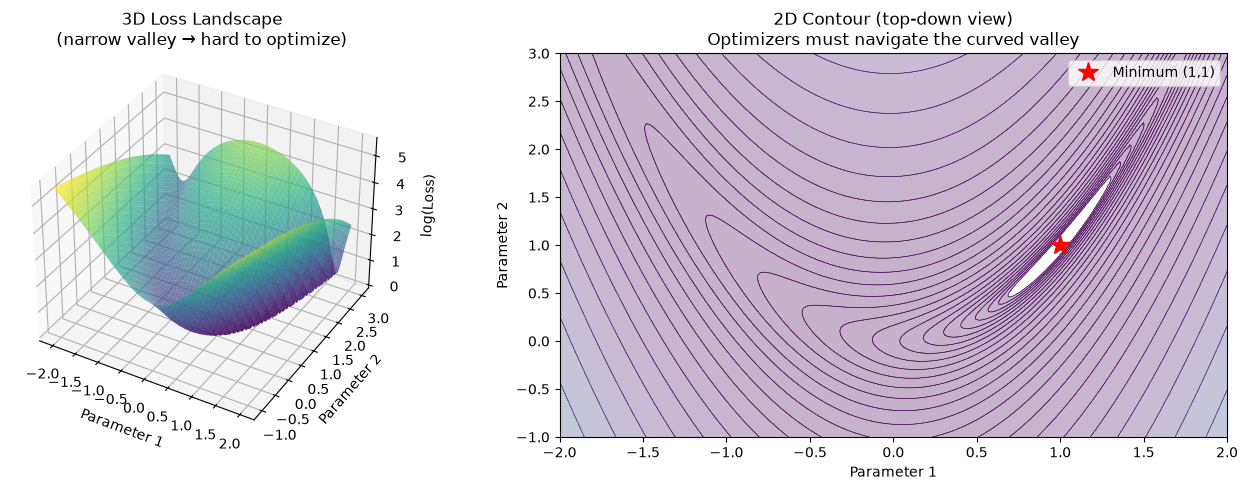

The valley curves from bottom-left to (1,1). SGD will struggle here.


In [29]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# ─── Define a tricky loss surface (Rosenbrock-like) ───
# The minimum is at (1, 1). There's a narrow curved valley that's
# easy to overshoot and hard to navigate.
def loss_fn(x, y):
    return (1 - x)**2 + 10 * (y - x**2)**2

# Create the surface
xx = np.linspace(-2, 2, 200)
yy = np.linspace(-1, 3, 200)
X, Y = np.meshgrid(xx, yy)
Z = loss_fn(X, Y)

# 3D surface plot
fig = plt.figure(figsize=(14, 5))

ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X, Y, np.log1p(Z), cmap='viridis', alpha=0.7, edgecolor='none')
ax1.set_xlabel('Parameter 1')
ax1.set_ylabel('Parameter 2')
ax1.set_zlabel('log(Loss)')
ax1.set_title('3D Loss Landscape\n(narrow valley → hard to optimize)')
ax1.view_init(elev=35, azim=-60)

# 2D contour plot (bird's eye view)
ax2 = fig.add_subplot(122)
levels = np.logspace(-1, 3, 30)
ax2.contour(X, Y, Z, levels=levels, cmap='viridis', linewidths=0.5)
ax2.contourf(X, Y, Z, levels=levels, cmap='viridis', alpha=0.3)
ax2.plot(1, 1, 'r*', markersize=15, label='Minimum (1,1)')
ax2.set_xlabel('Parameter 1')
ax2.set_ylabel('Parameter 2')
ax2.set_title('2D Contour (top-down view)\nOptimizers must navigate the curved valley')
ax2.legend()

plt.tight_layout()
plt.savefig('loss_landscape.png', dpi=150, bbox_inches='tight')
plt.show()
print("The valley curves from bottom-left to (1,1). SGD will struggle here.")

### 13a. Watch 4 Optimizers Race

Same starting point, same loss surface. Watch how each optimizer navigates differently:
- **SGD**: one learning rate, no memory
- **SGD + Momentum**: remembers previous direction  
- **Adam**: adaptive per-parameter learning rate + momentum
- **AdamW**: Adam + proper weight decay

/var/folders/zb/nx5l_0kn4gq8r2bq_mtb33580000gp/T/ipykernel_27412/2137926018.py:5: RuntimeWarning: overflow encountered in scalar power
  dx = -2*(1-x) + 10*2*(y - x**2)*(-2*x)
/var/folders/zb/nx5l_0kn4gq8r2bq_mtb33580000gp/T/ipykernel_27412/2137926018.py:6: RuntimeWarning: overflow encountered in scalar power
  dy = 10*2*(y - x**2)
/var/folders/zb/nx5l_0kn4gq8r2bq_mtb33580000gp/T/ipykernel_27412/2137926018.py:5: RuntimeWarning: invalid value encountered in scalar subtract
  dx = -2*(1-x) + 10*2*(y - x**2)*(-2*x)
/var/folders/zb/nx5l_0kn4gq8r2bq_mtb33580000gp/T/ipykernel_27412/2137926018.py:6: RuntimeWarning: invalid value encountered in scalar subtract
  dy = 10*2*(y - x**2)


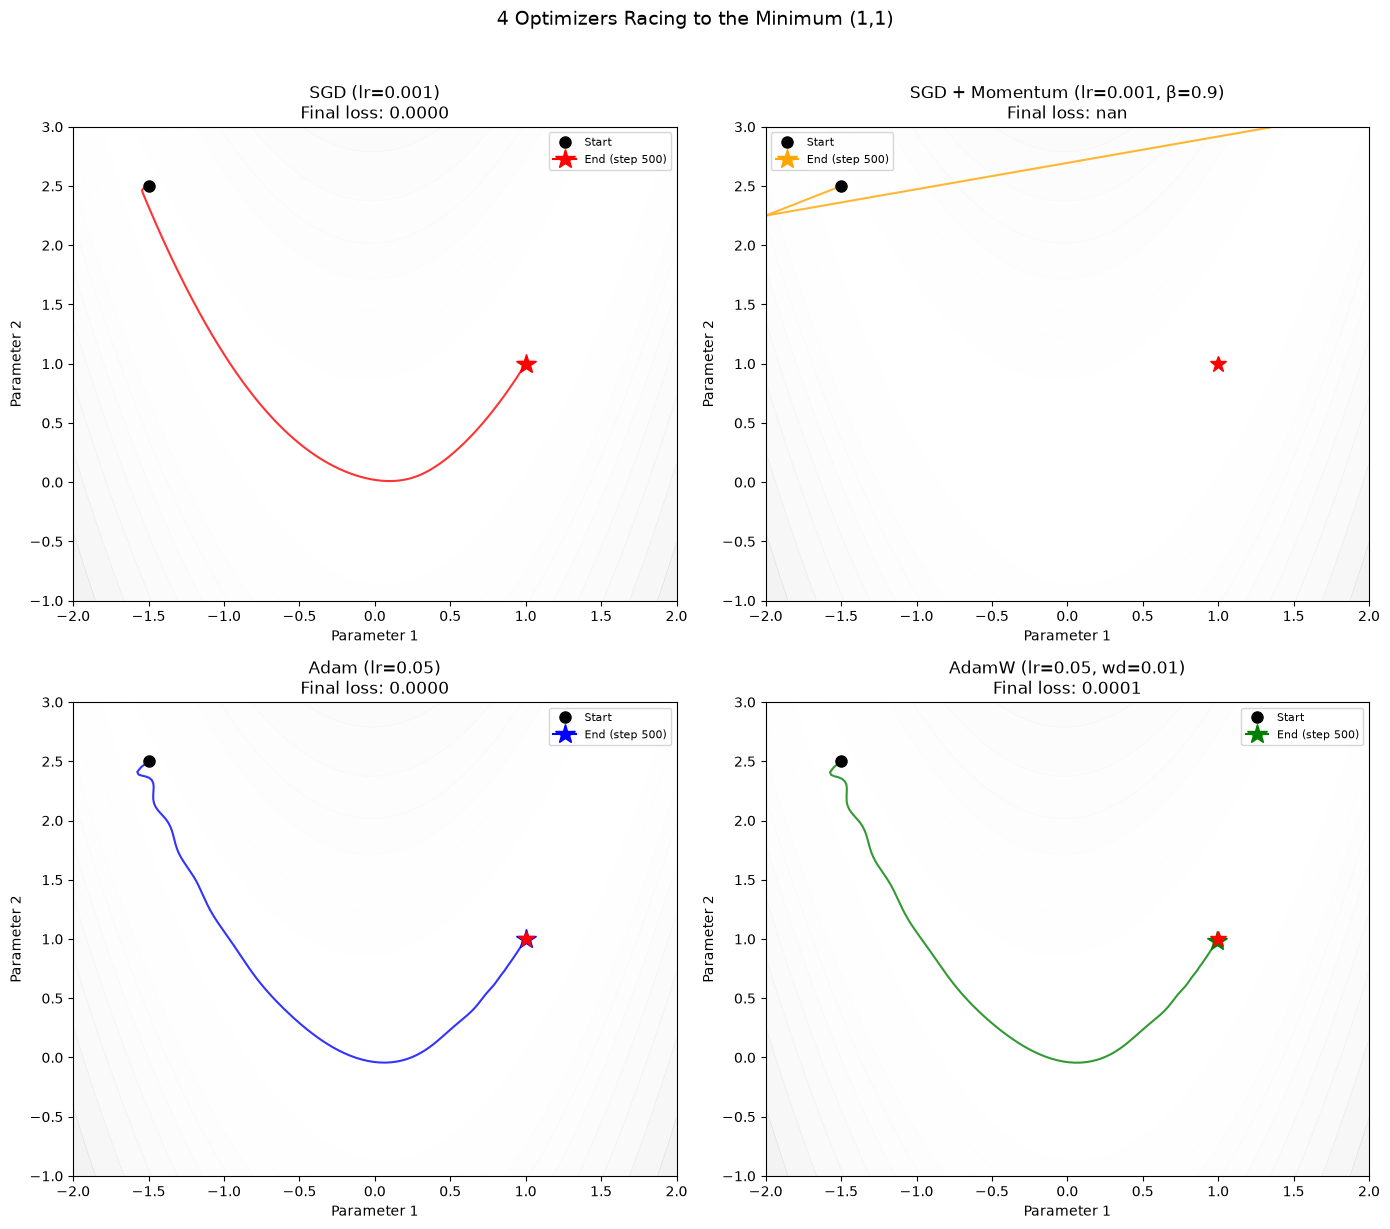

SGD: barely moves (lr too small, but larger lr would diverge)
Momentum: overshoots but finds the valley, then oscillates
Adam: adaptive LR lets it use a 50x higher LR, reaches minimum fast
AdamW: same as Adam but weight decay pulls params toward 0 slightly


In [54]:
# ─── Implement optimizers from scratch to record their paths ───

def gradient(x, y):
    """Gradient of the Rosenbrock function."""
    dx = -2*(1-x) + 10*2*(y - x**2)*(-2*x)
    dy = 10*2*(y - x**2)
    return np.array([dx, dy])

def run_sgd(start, lr, steps):
    path = [start.copy()]
    pos = start.copy()
    for _ in range(steps):
        g = gradient(pos[0], pos[1])
        pos = pos - lr * g
        path.append(pos.copy())
    return np.array(path)

def run_sgd_momentum(start, lr, steps, beta=0.9):
    path = [start.copy()]
    pos = start.copy()
    v = np.zeros(2)
    for _ in range(steps):
        g = gradient(pos[0], pos[1])
        v = beta * v + g
        pos = pos - lr * v
        path.append(pos.copy())
    return np.array(path)

def run_adam(start, lr, steps, beta1=0.9, beta2=0.999, eps=1e-8):
    path = [start.copy()]
    pos = start.copy()
    m = np.zeros(2)
    v = np.zeros(2)
    for t in range(1, steps + 1):
        g = gradient(pos[0], pos[1])
        m = beta1 * m + (1 - beta1) * g
        v = beta2 * v + (1 - beta2) * g**2
        m_hat = m / (1 - beta1**t)
        v_hat = v / (1 - beta2**t)
        pos = pos - lr * m_hat / (np.sqrt(v_hat) + eps)
        path.append(pos.copy())
    return np.array(path)

def run_adamw(start, lr, steps, beta1=0.9, beta2=0.999, eps=1e-8, wd=0.01):
    path = [start.copy()]
    pos = start.copy()
    m = np.zeros(2)
    v = np.zeros(2)
    for t in range(1, steps + 1):
        g = gradient(pos[0], pos[1])
        m = beta1 * m + (1 - beta1) * g
        v = beta2 * v + (1 - beta2) * g**2
        m_hat = m / (1 - beta1**t)
        v_hat = v / (1 - beta2**t)
        pos = pos - lr * m_hat / (np.sqrt(v_hat) + eps) - lr * wd * pos  # decoupled WD
        path.append(pos.copy())
    return np.array(path)

start = np.array([-1.5, 2.5])
steps = 500

sgd_path      = run_sgd(start, lr=0.0001, steps=10000000)
momentum_path = run_sgd_momentum(start, lr=0.05, steps=steps)
adam_path      = run_adam(start, lr=0.05, steps=steps)
adamw_path     = run_adamw(start, lr=0.05, steps=steps)

# ─── Plot all 4 paths on the contour ───
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
optimizers = [
    ("SGD (lr=0.001)", sgd_path, 'red'),
    ("SGD + Momentum (lr=0.001, β=0.9)", momentum_path, 'orange'),
    ("Adam (lr=0.05)", adam_path, 'blue'),
    ("AdamW (lr=0.05, wd=0.01)", adamw_path, 'green'),
]

for ax, (name, path, color) in zip(axes.flat, optimizers):
    levels = np.logspace(-1, 3, 30)
    ax.contourf(X, Y, Z, levels=levels, cmap='Greys', alpha=0.3)
    ax.contour(X, Y, Z, levels=levels, cmap='Greys', linewidths=0.3)
    
    # Plot path
    ax.plot(path[:, 0], path[:, 1], color=color, linewidth=1.5, alpha=0.8)
    ax.plot(path[0, 0], path[0, 1], 'ko', markersize=8, label='Start')
    ax.plot(path[-1, 0], path[-1, 1], color=color, marker='*', markersize=15, label=f'End (step {steps})')
    ax.plot(1, 1, 'r*', markersize=12)
    
    final_loss = loss_fn(path[-1, 0], path[-1, 1])
    ax.set_title(f'{name}\nFinal loss: {final_loss:.4f}')
    ax.set_xlabel('Parameter 1')
    ax.set_ylabel('Parameter 2')
    ax.legend(fontsize=8)
    ax.set_xlim(-2, 2)
    ax.set_ylim(-1, 3)

plt.suptitle('4 Optimizers Racing to the Minimum (1,1)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('optimizer_race.png', dpi=150, bbox_inches='tight')
plt.show()

print("SGD: barely moves (lr too small, but larger lr would diverge)")
print("Momentum: overshoots but finds the valley, then oscillates")
print("Adam: adaptive LR lets it use a 50x higher LR, reaches minimum fast")
print("AdamW: same as Adam but weight decay pulls params toward 0 slightly")

### 13b. WHY Adam Can Use 50x Higher Learning Rate

The key difference in one plot — how each optimizer's **effective learning rate** differs per parameter:

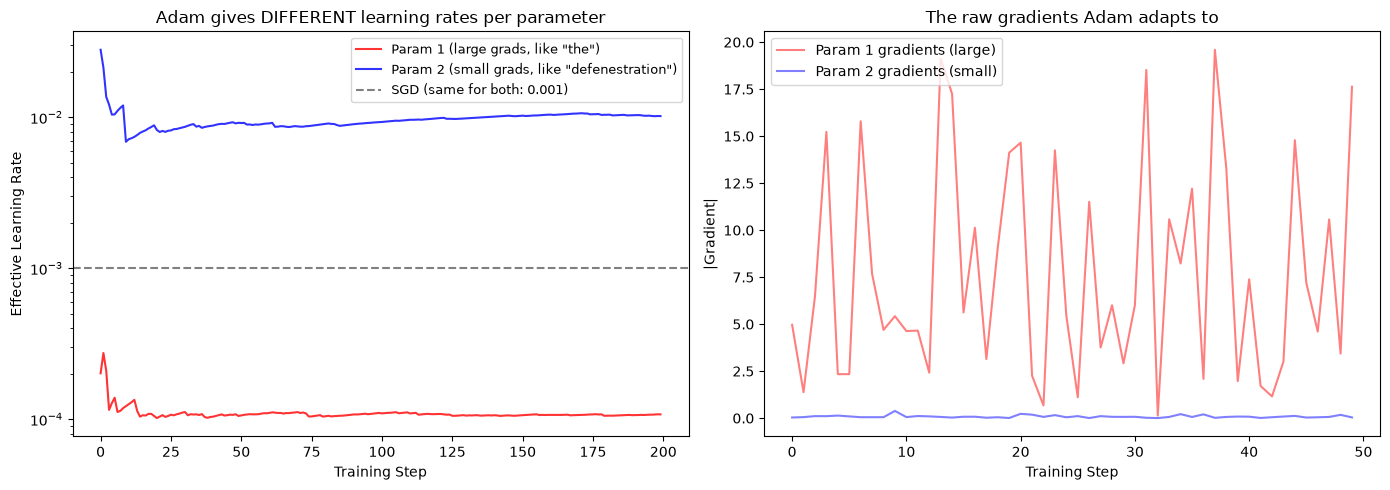

Red param (frequent token): Adam LOWERS its effective LR → prevents oscillation
Blue param (rare token):    Adam RAISES its effective LR  → learns faster
SGD uses the same LR for both → too big for red, too small for blue


In [55]:
# ─── Show how effective LR differs per parameter in Adam ───
# Simulate gradients for two parameters: one with large grads, one with small
np.random.seed(42)
steps = 200
grads_param1 = np.random.randn(steps) * 10    # large gradients (like "the" embedding)
grads_param2 = np.random.randn(steps) * 0.1   # small gradients (like "defenestration")

# SGD: same effective LR for both
lr_sgd = 0.001
sgd_updates1 = lr_sgd * np.abs(grads_param1)
sgd_updates2 = lr_sgd * np.abs(grads_param2)

# Adam: adaptive effective LR
lr_adam = 0.001
beta2 = 0.999
v1, v2 = 0, 0
adam_updates1, adam_updates2 = [], []
adam_eff_lr1, adam_eff_lr2 = [], []

for t in range(1, steps + 1):
    g1, g2 = grads_param1[t-1], grads_param2[t-1]
    v1 = beta2 * v1 + (1 - beta2) * g1**2
    v2 = beta2 * v2 + (1 - beta2) * g2**2
    v1_hat = v1 / (1 - beta2**t)
    v2_hat = v2 / (1 - beta2**t)
    eff1 = lr_adam / (np.sqrt(v1_hat) + 1e-8)
    eff2 = lr_adam / (np.sqrt(v2_hat) + 1e-8)
    adam_eff_lr1.append(eff1)
    adam_eff_lr2.append(eff2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot effective learning rates
ax1.plot(adam_eff_lr1, label='Param 1 (large grads, like "the")', color='red', alpha=0.8)
ax1.plot(adam_eff_lr2, label='Param 2 (small grads, like "defenestration")', color='blue', alpha=0.8)
ax1.axhline(y=lr_sgd, color='grey', linestyle='--', label=f'SGD (same for both: {lr_sgd})')
ax1.set_xlabel('Training Step')
ax1.set_ylabel('Effective Learning Rate')
ax1.set_title('Adam gives DIFFERENT learning rates per parameter')
ax1.legend(fontsize=9)
ax1.set_yscale('log')

# Plot the actual gradients for context
ax2.plot(np.abs(grads_param1[:50]), label='Param 1 gradients (large)', color='red', alpha=0.5)
ax2.plot(np.abs(grads_param2[:50]), label='Param 2 gradients (small)', color='blue', alpha=0.5)
ax2.set_xlabel('Training Step')
ax2.set_ylabel('|Gradient|')
ax2.set_title('The raw gradients Adam adapts to')
ax2.legend()

plt.tight_layout()
plt.savefig('adam_adaptive_lr.png', dpi=150, bbox_inches='tight')
plt.show()

print("Red param (frequent token): Adam LOWERS its effective LR → prevents oscillation")
print("Blue param (rare token):    Adam RAISES its effective LR  → learns faster")
print("SGD uses the same LR for both → too big for red, too small for blue")

### 13c. AdamW vs Adam — The Weight Decay Difference

Adam applies weight decay THROUGH the adaptive scaling (wrong).
AdamW applies weight decay DIRECTLY to weights (correct).

Watch how the two diverge over training:

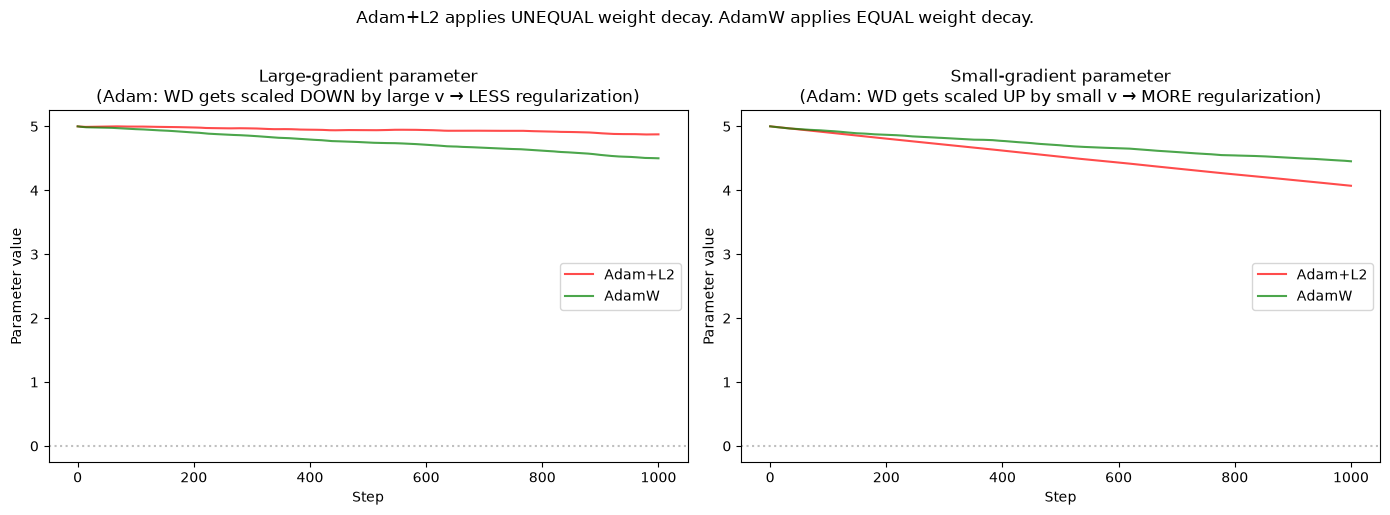

In Adam+L2: large-gradient params get LESS regularization (bad)
In AdamW:   ALL params get the SAME weight decay (correct)


In [56]:
# ─── Adam vs AdamW: weight decay behavior ───
# Track a single parameter with large gradients and one with small gradients
np.random.seed(42)
steps = 1000
lr = 0.001
wd = 0.1  # exaggerated for visibility
beta1, beta2, eps = 0.9, 0.999, 1e-8

# Param with LARGE gradients (v will be large → less WD in Adam)
# Param with SMALL gradients (v will be small → more WD in Adam)
grads_large = np.random.randn(steps) * 5.0
grads_small = np.random.randn(steps) * 0.1

def simulate_adam_wd(grads, lr, wd, steps):
    """Adam with L2 regularization (weight decay in gradient)."""
    theta = 5.0  # start far from 0
    m, v = 0, 0
    history = [theta]
    for t in range(1, steps + 1):
        g = grads[t-1] + wd * theta  # L2 regularization added to gradient!
        m = beta1 * m + (1 - beta1) * g
        v = beta2 * v + (1 - beta2) * g**2
        m_hat = m / (1 - beta1**t)
        v_hat = v / (1 - beta2**t)
        theta = theta - lr * m_hat / (np.sqrt(v_hat) + eps)
        history.append(theta)
    return np.array(history)

def simulate_adamw(grads, lr, wd, steps):
    """AdamW: decoupled weight decay."""
    theta = 5.0
    m, v = 0, 0
    history = [theta]
    for t in range(1, steps + 1):
        g = grads[t-1]  # NO weight decay in gradient
        m = beta1 * m + (1 - beta1) * g
        v = beta2 * v + (1 - beta2) * g**2
        m_hat = m / (1 - beta1**t)
        v_hat = v / (1 - beta2**t)
        theta = theta - lr * m_hat / (np.sqrt(v_hat) + eps) - lr * wd * theta  # WD applied directly
        history.append(theta)
    return np.array(history)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Large gradient parameter
adam_large = simulate_adam_wd(grads_large, lr, wd, steps)
adamw_large = simulate_adamw(grads_large, lr, wd, steps)
ax1.plot(adam_large, label='Adam+L2', color='red', alpha=0.7)
ax1.plot(adamw_large, label='AdamW', color='green', alpha=0.7)
ax1.axhline(y=0, color='grey', linestyle=':', alpha=0.5)
ax1.set_title('Large-gradient parameter\n(Adam: WD gets scaled DOWN by large v → LESS regularization)')
ax1.set_xlabel('Step')
ax1.set_ylabel('Parameter value')
ax1.legend()

# Small gradient parameter  
adam_small = simulate_adam_wd(grads_small, lr, wd, steps)
adamw_small = simulate_adamw(grads_small, lr, wd, steps)
ax2.plot(adam_small, label='Adam+L2', color='red', alpha=0.7)
ax2.plot(adamw_small, label='AdamW', color='green', alpha=0.7)
ax2.axhline(y=0, color='grey', linestyle=':', alpha=0.5)
ax2.set_title('Small-gradient parameter\n(Adam: WD gets scaled UP by small v → MORE regularization)')
ax2.set_xlabel('Step')
ax2.set_ylabel('Parameter value')
ax2.legend()

plt.suptitle('Adam+L2 applies UNEQUAL weight decay. AdamW applies EQUAL weight decay.', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('adam_vs_adamw.png', dpi=150, bbox_inches='tight')
plt.show()

print("In Adam+L2: large-gradient params get LESS regularization (bad)")
print("In AdamW:   ALL params get the SAME weight decay (correct)")

## 14. Visualizing Learning Rate Schedules

Why warmup? Why cosine decay? Watch how different schedules behave:

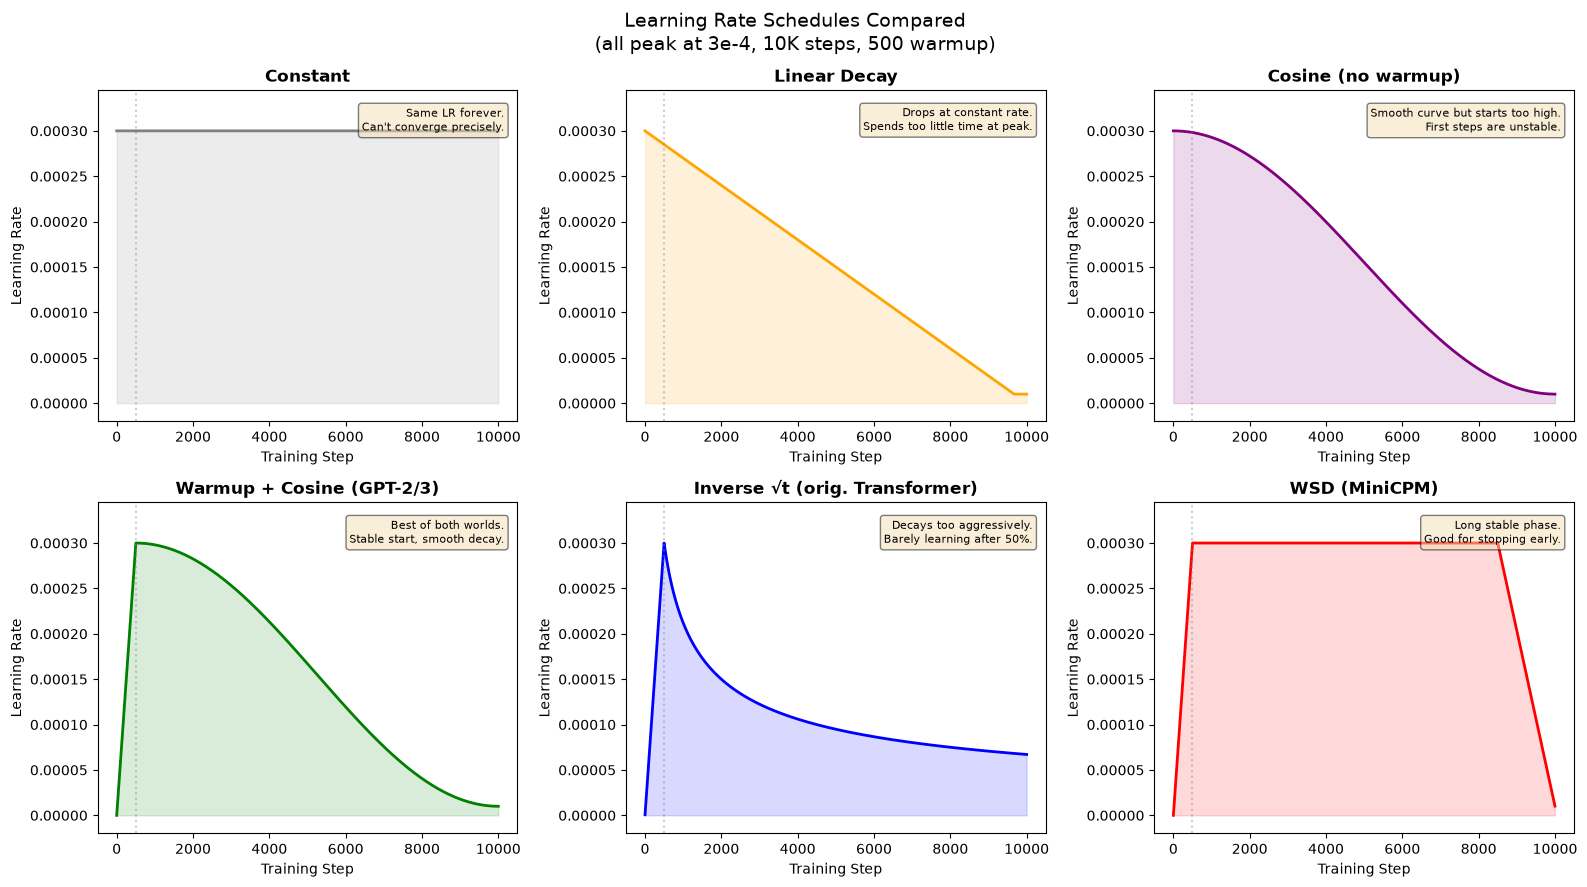

In [57]:
# ─── Learning Rate Schedules ───
total_steps = 10000
warmup_steps = 500
lr_max = 3e-4
lr_min = 1e-5

steps = np.arange(total_steps)

# 1. Constant
lr_constant = np.full(total_steps, lr_max)

# 2. Linear decay
lr_linear = lr_max * (1 - steps / total_steps)
lr_linear = np.maximum(lr_linear, lr_min)

# 3. Cosine decay (no warmup)
lr_cosine_no_warmup = lr_min + 0.5 * (lr_max - lr_min) * (1 + np.cos(np.pi * steps / total_steps))

# 4. Warmup + Cosine decay (what GPT uses)
lr_warmup_cosine = np.zeros(total_steps)
for t in range(total_steps):
    if t < warmup_steps:
        lr_warmup_cosine[t] = lr_max * t / warmup_steps  # linear warmup
    else:
        progress = (t - warmup_steps) / (total_steps - warmup_steps)
        lr_warmup_cosine[t] = lr_min + 0.5 * (lr_max - lr_min) * (1 + np.cos(np.pi * progress))

# 5. Inverse sqrt (original Transformer)
d_model = 768
lr_invsqrt = np.zeros(total_steps)
for t in range(total_steps):
    t1 = t + 1
    lr_invsqrt[t] = d_model**(-0.5) * min(t1**(-0.5), t1 * warmup_steps**(-1.5))
lr_invsqrt = lr_invsqrt / lr_invsqrt.max() * lr_max  # normalize to same peak

# 6. WSD (Warmup-Stable-Decay)
lr_wsd = np.zeros(total_steps)
stable_end = int(0.85 * total_steps)
decay_start = stable_end
for t in range(total_steps):
    if t < warmup_steps:
        lr_wsd[t] = lr_max * t / warmup_steps
    elif t < decay_start:
        lr_wsd[t] = lr_max
    else:
        progress = (t - decay_start) / (total_steps - decay_start)
        lr_wsd[t] = lr_max * (1 - progress) + lr_min * progress

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
schedules = [
    ("Constant", lr_constant, "grey", "Same LR forever.\nCan't converge precisely."),
    ("Linear Decay", lr_linear, "orange", "Drops at constant rate.\nSpends too little time at peak."),
    ("Cosine (no warmup)", lr_cosine_no_warmup, "purple", "Smooth curve but starts too high.\nFirst steps are unstable."),
    ("Warmup + Cosine (GPT-2/3)", lr_warmup_cosine, "green", "Best of both worlds.\nStable start, smooth decay."),
    ("Inverse √t (orig. Transformer)", lr_invsqrt, "blue", "Decays too aggressively.\nBarely learning after 50%."),
    ("WSD (MiniCPM)", lr_wsd, "red", "Long stable phase.\nGood for stopping early."),
]

for ax, (name, lr, color, desc) in zip(axes.flat, schedules):
    ax.fill_between(steps, lr, alpha=0.15, color=color)
    ax.plot(steps, lr, color=color, linewidth=2)
    ax.axvline(x=warmup_steps, color='grey', linestyle=':', alpha=0.4, label='warmup end')
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Training Step')
    ax.set_ylabel('Learning Rate')
    ax.text(0.97, 0.95, desc, transform=ax.transAxes, fontsize=8,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    ax.set_ylim(-0.00002, lr_max * 1.15)

plt.suptitle('Learning Rate Schedules Compared\n(all peak at 3e-4, 10K steps, 500 warmup)', fontsize=14)
plt.tight_layout()
plt.savefig('lr_schedules.png', dpi=150, bbox_inches='tight')
plt.show()

### 14a. WHY Warmup Matters — Watch Training Stability

Let's actually train our tiny model with and without warmup and see the difference:

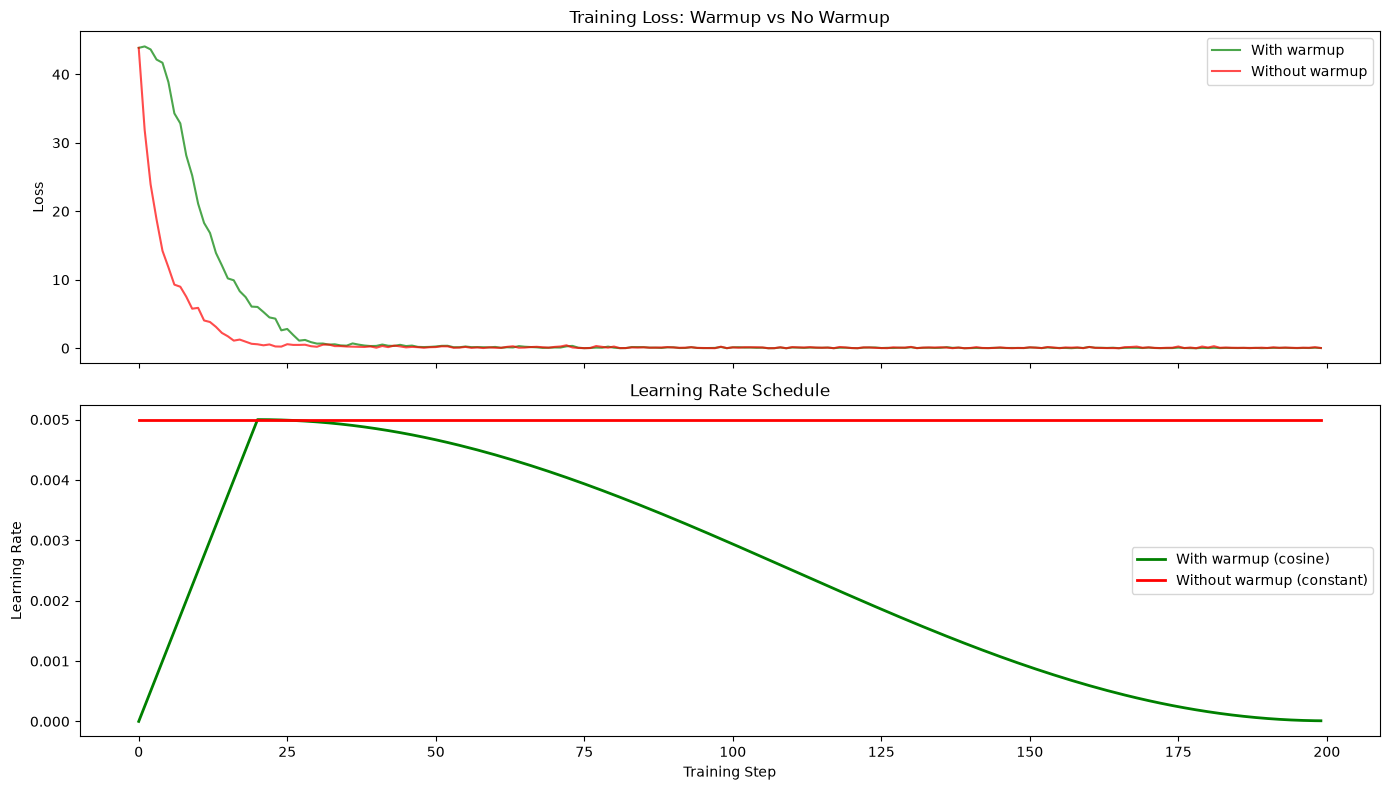

Final loss WITH warmup:    0.0290
Final loss WITHOUT warmup: 0.0319

Watch the first ~20 steps: without warmup, loss can spike wildly.
Warmup lets the optimizer 'find its footing' before taking big steps.


In [58]:
# ─── Train with vs without warmup ───
torch.manual_seed(42)
model_warmup = GPTModel(TINY_CONFIG)
model_no_warmup = GPTModel(TINY_CONFIG)
# Start from same weights
model_no_warmup.load_state_dict(model_warmup.state_dict())

opt_warmup = torch.optim.AdamW(model_warmup.parameters(), lr=5e-3, weight_decay=0.01)
opt_no_warmup = torch.optim.AdamW(model_no_warmup.parameters(), lr=5e-3, weight_decay=0.01)

warmup_steps_total = 20
total_train_steps = 200

losses_warmup = []
losses_no_warmup = []
lrs_warmup = []
lrs_no_warmup = []

step = 0
for epoch in range(15):
    for x_batch, y_batch in train_loader:
        # ── Model WITH warmup ──
        if step < warmup_steps_total:
            current_lr = 5e-3 * step / warmup_steps_total
        else:
            progress = (step - warmup_steps_total) / (total_train_steps - warmup_steps_total)
            current_lr = 1e-5 + 0.5 * (5e-3 - 1e-5) * (1 + np.cos(np.pi * min(progress, 1.0)))
        for pg in opt_warmup.param_groups:
            pg['lr'] = current_lr
        lrs_warmup.append(current_lr)
        
        opt_warmup.zero_grad()
        logits = model_warmup(x_batch)
        loss = F.cross_entropy(logits.view(-1, logits.size(-1)), y_batch.view(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_warmup.parameters(), 1.0)
        opt_warmup.step()
        losses_warmup.append(loss.item())
        
        # ── Model WITHOUT warmup (full LR from step 0) ──
        lrs_no_warmup.append(5e-3)
        opt_no_warmup.zero_grad()
        logits2 = model_no_warmup(x_batch)
        loss2 = F.cross_entropy(logits2.view(-1, logits2.size(-1)), y_batch.view(-1))
        loss2.backward()
        torch.nn.utils.clip_grad_norm_(model_no_warmup.parameters(), 1.0)
        opt_no_warmup.step()
        losses_no_warmup.append(loss2.item())
        
        step += 1
        if step >= total_train_steps:
            break
    if step >= total_train_steps:
        break

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax1.plot(losses_warmup, label='With warmup', color='green', alpha=0.7)
ax1.plot(losses_no_warmup, label='Without warmup', color='red', alpha=0.7)
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss: Warmup vs No Warmup')
ax1.legend()

ax2.plot(lrs_warmup, label='With warmup (cosine)', color='green', linewidth=2)
ax2.plot(lrs_no_warmup, label='Without warmup (constant)', color='red', linewidth=2)
ax2.set_xlabel('Training Step')
ax2.set_ylabel('Learning Rate')
ax2.set_title('Learning Rate Schedule')
ax2.legend()

plt.tight_layout()
plt.savefig('warmup_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Final loss WITH warmup:    {losses_warmup[-1]:.4f}")
print(f"Final loss WITHOUT warmup: {losses_no_warmup[-1]:.4f}")
print("\nWatch the first ~20 steps: without warmup, loss can spike wildly.")
print("Warmup lets the optimizer 'find its footing' before taking big steps.")

## 15. Visualizing Gradient Clipping

What happens when a single bad batch produces enormous gradients? Clipping saves the model.

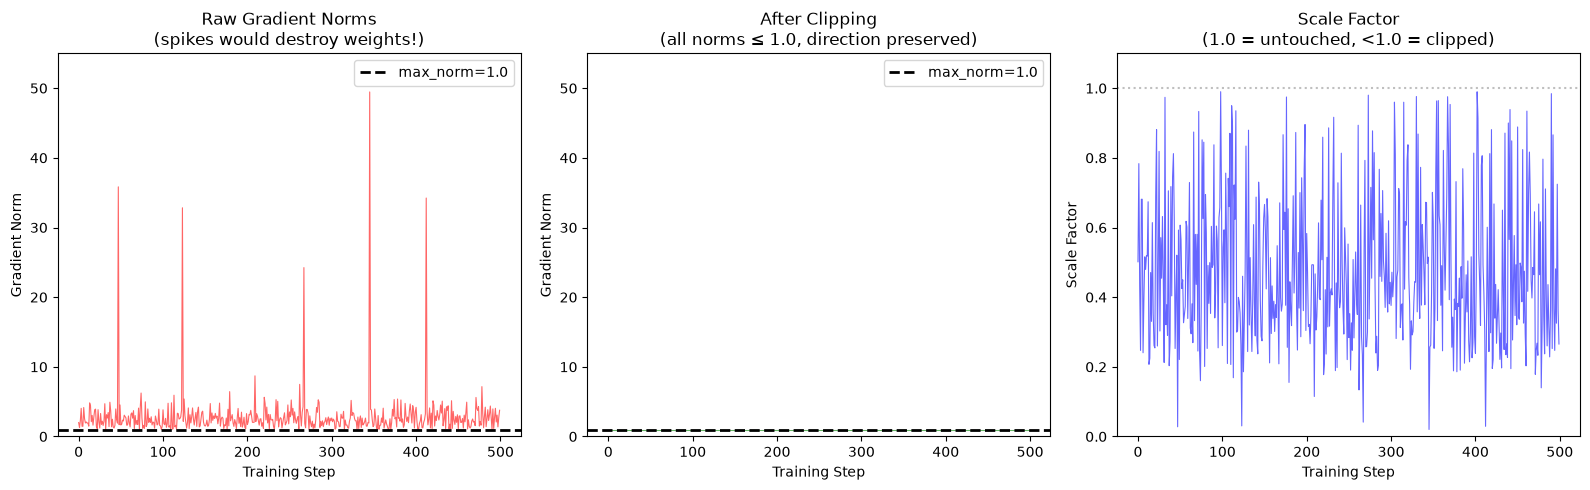

100% of steps were clipped (gradient norm > 1.0)
Worst spike: 49.5x the normal range
Without clipping, that spike would update weights 49x more than normal


In [35]:
# ─── Gradient clipping visualization ───
np.random.seed(42)

# Simulate gradient norms over 500 training steps
# Most are normal (1-5), but a few "bad batches" produce spikes
grad_norms = np.abs(np.random.randn(500)) * 2 + 1  # normal: 1-5
# Inject spikes
for spike_pos in [47, 123, 267, 345, 412]:
    grad_norms[spike_pos] = np.random.uniform(10, 50)

max_norm = 1.0

# Clipped norms
clipped_norms = np.minimum(grad_norms, max_norm)
scale_factors = np.minimum(max_norm / grad_norms, 1.0)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Raw gradient norms
ax = axes[0]
ax.plot(grad_norms, color='red', alpha=0.6, linewidth=0.8)
ax.axhline(y=max_norm, color='black', linestyle='--', linewidth=2, label=f'max_norm={max_norm}')
ax.set_title('Raw Gradient Norms\n(spikes would destroy weights!)')
ax.set_xlabel('Training Step')
ax.set_ylabel('Gradient Norm')
ax.legend()
ax.set_ylim(0, 55)

# 2. After clipping
ax = axes[1]
ax.plot(clipped_norms, color='green', alpha=0.6, linewidth=0.8)
ax.axhline(y=max_norm, color='black', linestyle='--', linewidth=2, label=f'max_norm={max_norm}')
ax.set_title('After Clipping\n(all norms ≤ 1.0, direction preserved)')
ax.set_xlabel('Training Step')
ax.set_ylabel('Gradient Norm')
ax.legend()
ax.set_ylim(0, 55)

# 3. Scale factor (how much each gradient was shrunk)
ax = axes[2]
ax.plot(scale_factors, color='blue', alpha=0.6, linewidth=0.8)
ax.axhline(y=1.0, color='grey', linestyle=':', alpha=0.5)
ax.set_title('Scale Factor\n(1.0 = untouched, <1.0 = clipped)')
ax.set_xlabel('Training Step')
ax.set_ylabel('Scale Factor')
ax.set_ylim(0, 1.1)

plt.tight_layout()
plt.savefig('gradient_clipping.png', dpi=150, bbox_inches='tight')
plt.show()

pct_clipped = np.mean(grad_norms > max_norm) * 100
print(f"{pct_clipped:.0f}% of steps were clipped (gradient norm > {max_norm})")
print(f"Worst spike: {grad_norms.max():.1f}x the normal range")
print(f"Without clipping, that spike would update weights {grad_norms.max():.0f}x more than normal")

### 15a. Gradient Clipping in 2D — Direction Preserved

The key property: clipping scales the gradient **uniformly**, so the direction stays the same:

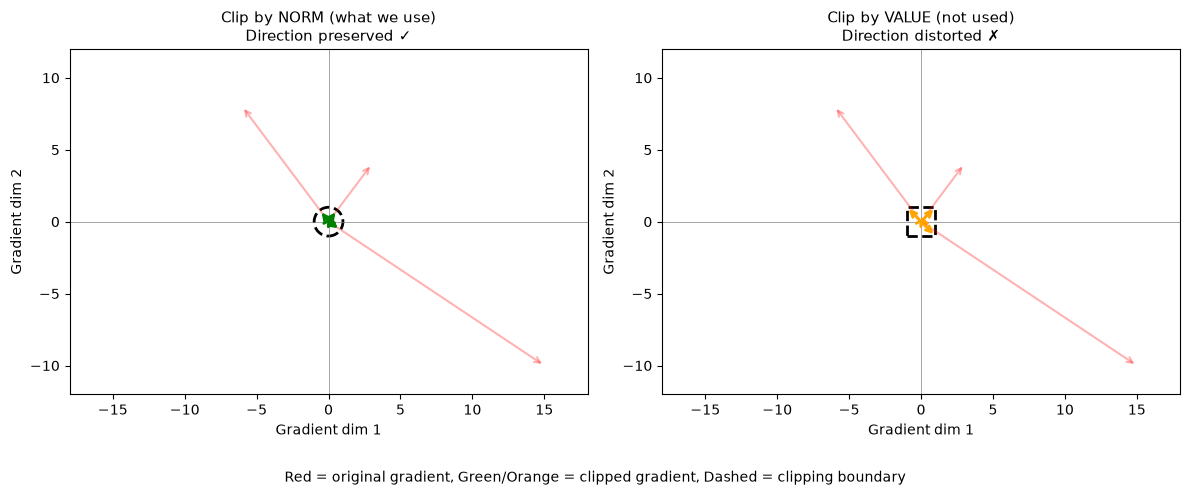

Clip by norm: all green arrows point the SAME direction as their red originals
Clip by value: orange arrows point DIFFERENT directions (e.g., (15,-10) → (1,-1) = 45° rotation!)


In [36]:
# ─── 2D gradient clipping: direction preserved ───
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Example gradients (some normal, some huge)
gradients = [
    np.array([0.3, 0.4]),
    np.array([0.8, -0.2]),
    np.array([3.0, 4.0]),     # norm = 5.0, will be clipped
    np.array([-6.0, 8.0]),    # norm = 10.0, will be clipped
    np.array([15.0, -10.0]),  # norm = 18.0, will be clipped heavily
]
max_norm = 1.0

# CLIP BY NORM (correct — preserves direction)
ax1.set_title('Clip by NORM (what we use)\nDirection preserved ✓', fontsize=11)
for g in gradients:
    norm = np.linalg.norm(g)
    ax1.annotate('', xy=g, xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='red', alpha=0.3, lw=1.5))
    if norm > max_norm:
        g_clipped = g * max_norm / norm
        ax1.annotate('', xy=g_clipped, xytext=(0, 0),
                    arrowprops=dict(arrowstyle='->', color='green', lw=2))
    else:
        ax1.annotate('', xy=g, xytext=(0, 0),
                    arrowprops=dict(arrowstyle='->', color='green', lw=2))

circle = plt.Circle((0, 0), max_norm, fill=False, color='black', linestyle='--', linewidth=2)
ax1.add_patch(circle)
ax1.set_xlim(-18, 18)
ax1.set_ylim(-12, 12)
ax1.set_aspect('equal')
ax1.axhline(y=0, color='grey', linewidth=0.5)
ax1.axvline(x=0, color='grey', linewidth=0.5)
ax1.set_xlabel('Gradient dim 1')
ax1.set_ylabel('Gradient dim 2')

# CLIP BY VALUE (wrong — distorts direction)
ax2.set_title('Clip by VALUE (not used)\nDirection distorted ✗', fontsize=11)
for g in gradients:
    ax2.annotate('', xy=g, xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='red', alpha=0.3, lw=1.5))
    g_clipped = np.clip(g, -max_norm, max_norm)
    ax2.annotate('', xy=g_clipped, xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='orange', lw=2))

rect = plt.Rectangle((-max_norm, -max_norm), 2*max_norm, 2*max_norm,
                     fill=False, color='black', linestyle='--', linewidth=2)
ax2.add_patch(rect)
ax2.set_xlim(-18, 18)
ax2.set_ylim(-12, 12)
ax2.set_aspect('equal')
ax2.axhline(y=0, color='grey', linewidth=0.5)
ax2.axvline(x=0, color='grey', linewidth=0.5)
ax2.set_xlabel('Gradient dim 1')
ax2.set_ylabel('Gradient dim 2')

# Legend
from matplotlib.patches import FancyArrowPatch
fig.text(0.5, -0.02, 'Red = original gradient, Green/Orange = clipped gradient, Dashed = clipping boundary',
         ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('clip_by_norm_vs_value.png', dpi=150, bbox_inches='tight')
plt.show()

print("Clip by norm: all green arrows point the SAME direction as their red originals")
print("Clip by value: orange arrows point DIFFERENT directions (e.g., (15,-10) → (1,-1) = 45° rotation!)")

## 16. 3D View — How the Loss Landscape Changes During Training

Watch the optimizer navigate from the high plateau down into the valley:

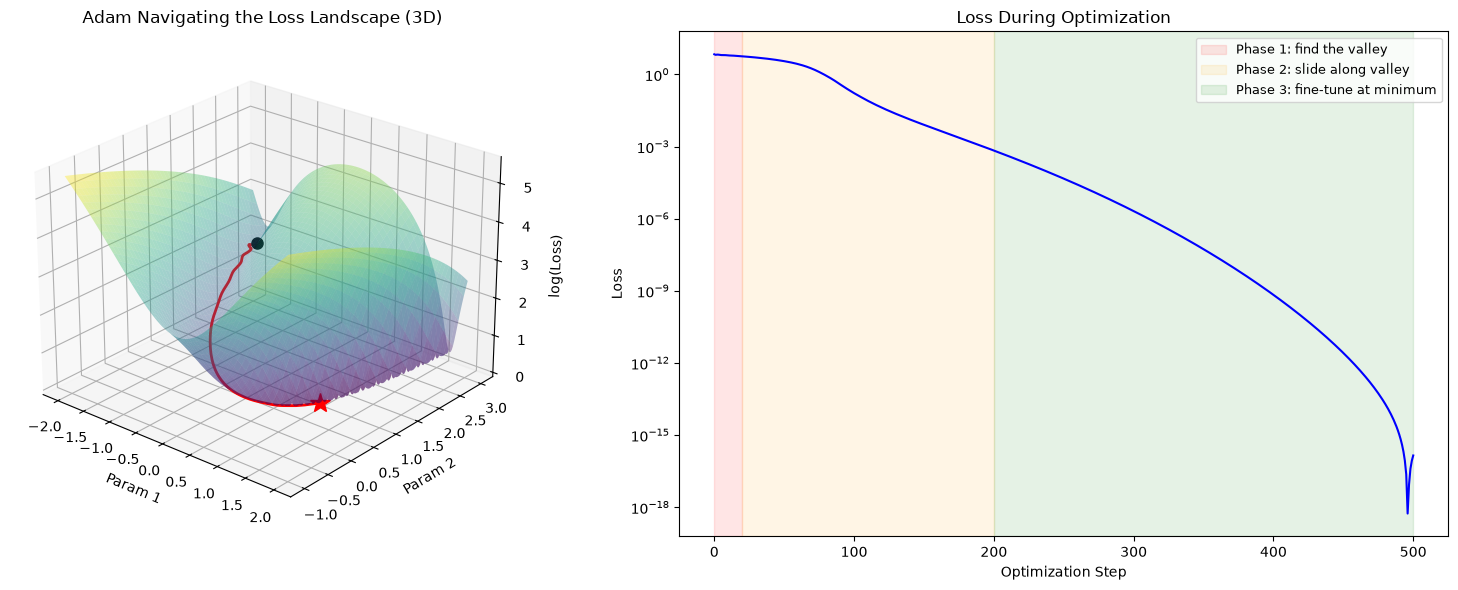

Phase 1 (red):   Rapid descent — finding the valley (like first few epochs)
Phase 2 (orange): Navigating the curved valley floor (most of training)
Phase 3 (green):  Fine adjustments near minimum (diminishing returns)


In [37]:
# ─── 3D path of Adam optimizer on the loss surface ───
fig = plt.figure(figsize=(16, 6))

# 3D surface with Adam path
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X, Y, np.log1p(Z), cmap='viridis', alpha=0.4, edgecolor='none')

# Adam path in 3D
path = adam_path[:200]
path_z = np.array([np.log1p(loss_fn(p[0], p[1])) for p in path])
ax1.plot(path[:, 0], path[:, 1], path_z, 'r-', linewidth=2, label='Adam path')
ax1.plot([path[0, 0]], [path[0, 1]], [path_z[0]], 'ko', markersize=8)
ax1.plot([path[-1, 0]], [path[-1, 1]], [path_z[-1]], 'r*', markersize=15)
ax1.set_xlabel('Param 1')
ax1.set_ylabel('Param 2')
ax1.set_zlabel('log(Loss)')
ax1.set_title('Adam Navigating the Loss Landscape (3D)')
ax1.view_init(elev=25, azim=-50)

# Loss over steps
ax2 = fig.add_subplot(122)
all_losses = [loss_fn(p[0], p[1]) for p in adam_path]
ax2.plot(all_losses, color='blue', linewidth=1.5)
ax2.set_xlabel('Optimization Step')
ax2.set_ylabel('Loss')
ax2.set_title('Loss During Optimization')
ax2.set_yscale('log')

# Annotate phases
ax2.axvspan(0, 20, alpha=0.1, color='red', label='Phase 1: find the valley')
ax2.axvspan(20, 200, alpha=0.1, color='orange', label='Phase 2: slide along valley')
ax2.axvspan(200, 500, alpha=0.1, color='green', label='Phase 3: fine-tune at minimum')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('3d_optimization.png', dpi=150, bbox_inches='tight')
plt.show()

print("Phase 1 (red):   Rapid descent — finding the valley (like first few epochs)")
print("Phase 2 (orange): Navigating the curved valley floor (most of training)")
print("Phase 3 (green):  Fine adjustments near minimum (diminishing returns)")

## 17. Batch Size Effect — Gradient Noise

Larger batches = cleaner gradients = smoother path, but each step costs more:

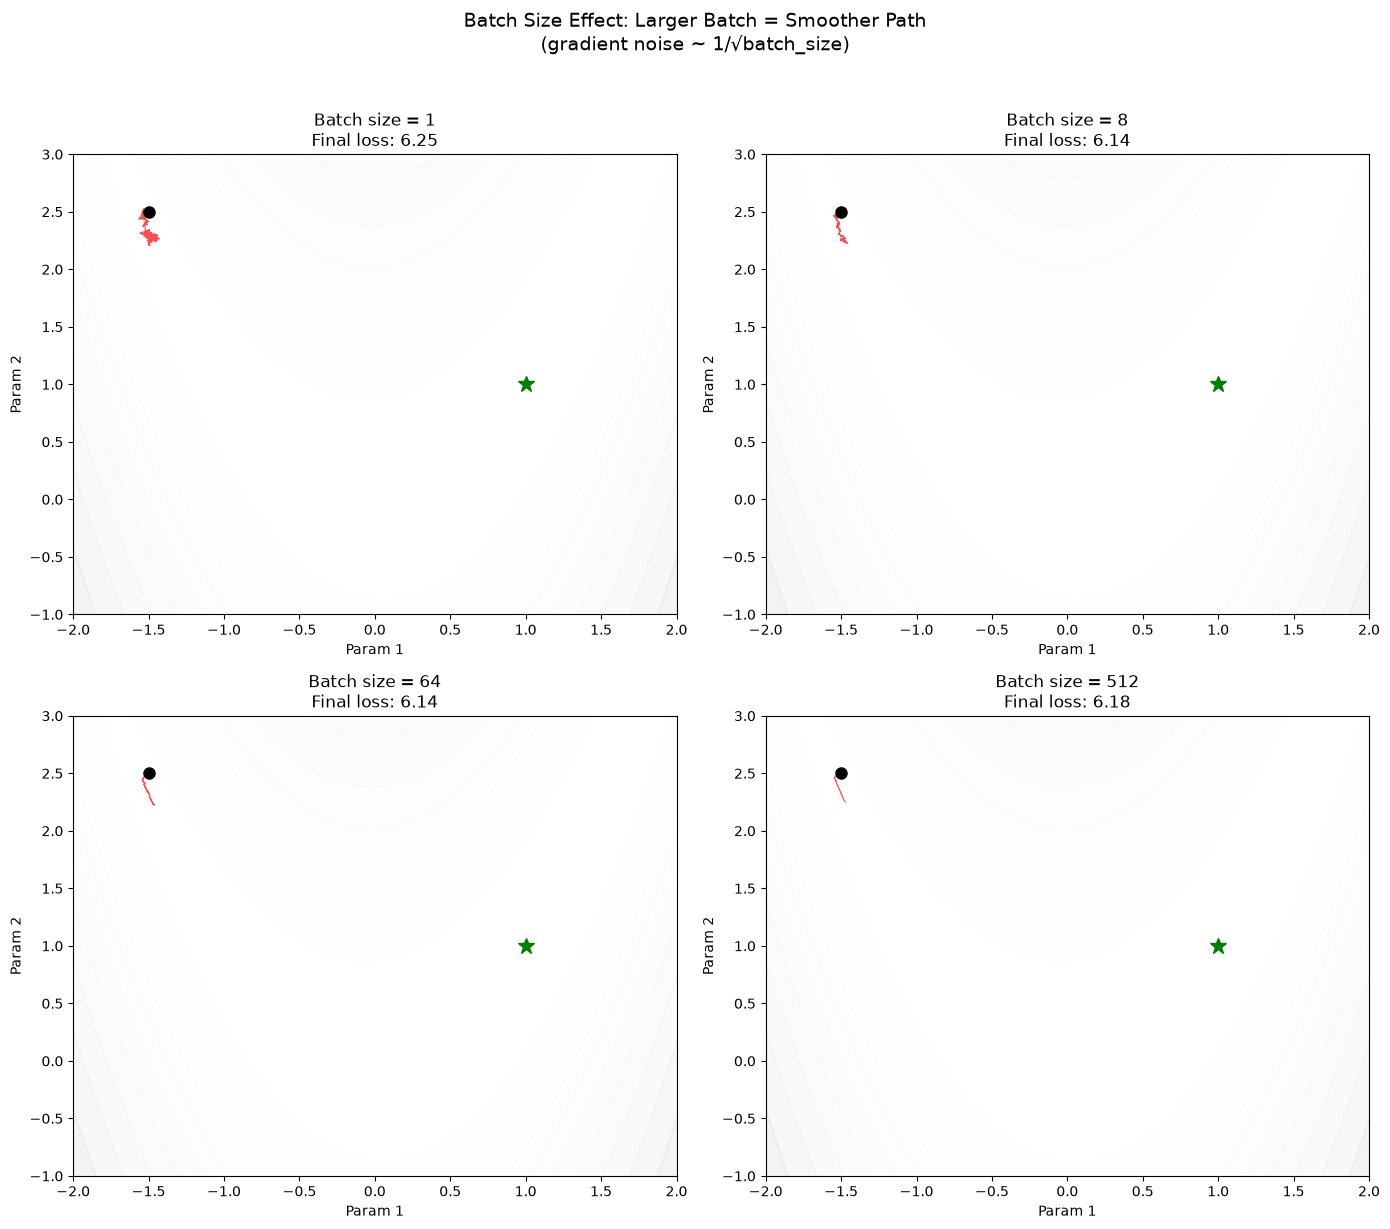

Batch  1:   Very noisy, random walk, might not converge
Batch  8:   Still noisy, but moving in roughly the right direction
Batch  64:  Much smoother, finds the valley efficiently
Batch  512: Very smooth, but each step needs 512 examples (expensive)

Sweet spot depends on your compute budget and dataset size.


In [38]:
# ─── Simulate different batch sizes ───
# "True" gradient at a point + random noise inversely proportional to batch size
np.random.seed(42)

def noisy_gradient(x, y, batch_size):
    true_grad = gradient(x, y)
    noise = np.random.randn(2) * 20.0 / np.sqrt(batch_size)  # noise ~ 1/√B
    return true_grad + noise

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
batch_sizes = [1, 8, 64, 512]

for ax, bs in zip(axes.flat, batch_sizes):
    levels = np.logspace(-1, 3, 30)
    ax.contourf(X, Y, Z, levels=levels, cmap='Greys', alpha=0.3)
    ax.contour(X, Y, Z, levels=levels, cmap='Greys', linewidths=0.3)
    
    # Run SGD with noisy gradients
    pos = np.array([-1.5, 2.5])
    path = [pos.copy()]
    lr = 0.0005
    for step in range(300):
        g = noisy_gradient(pos[0], pos[1], bs)
        pos = pos - lr * g
        pos = np.clip(pos, -2.5, 3.5)
        path.append(pos.copy())
    path = np.array(path)
    
    ax.plot(path[:, 0], path[:, 1], color='red', linewidth=0.8, alpha=0.7)
    ax.plot(path[0, 0], path[0, 1], 'ko', markersize=8)
    ax.plot(1, 1, 'g*', markersize=12)
    
    final_loss = loss_fn(path[-1, 0], path[-1, 1])
    ax.set_title(f'Batch size = {bs}\nFinal loss: {final_loss:.2f}', fontsize=12)
    ax.set_xlim(-2, 2)
    ax.set_ylim(-1, 3)
    ax.set_xlabel('Param 1')
    ax.set_ylabel('Param 2')

plt.suptitle('Batch Size Effect: Larger Batch = Smoother Path\n(gradient noise ~ 1/√batch_size)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('batch_size_effect.png', dpi=150, bbox_inches='tight')
plt.show()

print("Batch  1:   Very noisy, random walk, might not converge")
print("Batch  8:   Still noisy, but moving in roughly the right direction")
print("Batch  64:  Much smoother, finds the valley efficiently")
print("Batch  512: Very smooth, but each step needs 512 examples (expensive)")
print("\nSweet spot depends on your compute budget and dataset size.")

## Next Steps

Everything above visualizes the theory behind Section 5.2. Coming up:
- **Phase 7 code**: `GPTDatasetV1` + `create_dataloader_v1` in `minigpt/`
- **Phase 8 code**: Full training loop with AdamW + warmup + cosine + clipping
- **Section 5.3**: Temperature, top-k, and top-p sampling
- **Section 5.4**: Loading pretrained GPT-2 weights from OpenAI